# Self-Refine Self-Play Analysis

Does letting a model internally draft, critique, and refine its response improve its negotiation outcomes in self-play?

This notebook compares **self-refine** (generate → critique → refine → send) against **baseline** (generate → send) under identical conditions.  Both players always use the same model; the only thing that varies is the strategy.

Set `MODEL_SIZE` below to switch between size tiers. 

In [31]:
MODEL_SIZE = "medium"   # "small" | "medium"

In [32]:
import os, sys, re, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({"font.size": 22})
sns.set(font_scale=2.4)

def _find_repo_root():
    cur = Path(os.getcwd()).resolve()
    for parent in [cur, *cur.parents]:
        if (parent / "explorer" / "analysis" / "common.py").exists():
            return parent
    raise RuntimeError("Could not locate repo root (explorer/analysis/common.py not found)")

_REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(_REPO_ROOT / "explorer"))
from analysis.common import LOGS_ROOT, clean_name, resource_value  # noqa: E402

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

SELF_REFINE_ROOT = Path(LOGS_ROOT) / "self_refine"
GAMES = {
    "trading_self_refine_v1":   "Trading",
    "ultimatum_self_refine_v1": "Ultimatum",
    "buysell_self_refine_v1":   "BuySell",
}

# Symmetric strategies (used in §1–§5)
STRATEGIES = ["baseline", "self_refine"]
STRATEGY_COLORS = {
    "baseline":    "#7f7f7f",
    "self_refine": "#d62728",
}

# Cross-play conditions (used in §6)
COND_ORDER = ["base × base", "refine × refine", "base × refine", "refine × base"]
COND_COLORS = {
    "base × base":     "#7f7f7f",
    "refine × refine": "#d62728",
    "base × refine":   "#1f77b4",
    "refine × base":   "#ff7f0e",
}

def cond_label(p1: str, p2: str) -> str:
    s = {"default": "base", "self_refine": "refine"}
    return f"{s.get(p1, p1)} × {s.get(p2, p2)}"

SIZE_LABEL = MODEL_SIZE.replace("_", " ").title()
print(f"Model size : {SIZE_LABEL}")
print(f"Logs root  : {SELF_REFINE_ROOT}")


Model size : Medium
Logs root  : /home/adriano/Desktop/MultiAgent-Negotiation/.logs/self_refine


## Experimental Design

| Dimension | Value |
|--|-|
| **Strategies** | `baseline` (one-shot) vs `self_refine` (draft → feedback → refine → send) |
| **Games** | Trading, Ultimatum, BuySell |
| **Play mode** | Self-play (same model on both sides, same strategy on both sides) |
| **Models (medium)** | gemma-3-27b-it, mistral-small-3.2-24b, qwen3.5-27b |
| **Models (small)** | gemma-3-12b-it, ministral-3-14b-instruct, qwen3-14b |


In [33]:
STRATEGY_SUFFIX_RE = re.compile(r"_([a-z_]+)P1_([a-z_]+)P2$")

def _strip_strategy_suffix(piece: str):
    m = STRATEGY_SUFFIX_RE.search(piece)
    if m:
        return piece[:m.start()], m.group(1), m.group(2)
    return piece, None, None

def _synth_strategy(p1: str, p2: str) -> str:
    if p1 == p2 == "default":
        return "baseline"
    if p1 == p2:
        return p1
    return f"{p1}P1_{p2}P2"

def parse_run_path(game_state_path: Path) -> dict:
    parts = game_state_path.parts
    idx = parts.index("self_refine")
    experiment, size = parts[idx + 1], parts[idx + 2]
    p1_strategy = p2_strategy = None
    for piece in reversed(parts[idx + 3 : -1]):
        _, p1, p2 = _strip_strategy_suffix(piece)
        if p1:
            p1_strategy, p2_strategy = p1, p2
            break
    strategy = _synth_strategy(p1_strategy, p2_strategy) if p1_strategy else None
    run_id = parts[-2]
    pair, _, _ = _strip_strategy_suffix(parts[idx + 3])
    return dict(
        experiment=experiment, size=size, pair=pair,
        strategy=strategy,
        p1_strategy=p1_strategy, p2_strategy=p2_strategy,
        run_id=run_id,
    )


def extract_outcome(game_prefix: str, data: dict) -> dict:
    gs = data["game_state"]
    last = gs[-1]
    completed = last.get("current_iteration") == "END"
    turn_states = [s for s in gs if s.get("current_iteration") not in ("START", "END")]
    out = dict(
        game=game_prefix,
        completed=completed,
        num_turns=len(turn_states),
        total_parse_retries=data.get("total_parse_retries", 0),
        model_1=data["players"][0].get("model_id", data["players"][0].get("model")),
        model_2=data["players"][1].get("model_id", data["players"][1].get("model")),
    )
    if not completed:
        return out
    summary = last.get("summary", {})
    out["final_response"] = summary.get("final_response")
    out["deal"] = summary.get("final_response") == "ACCEPT"
    if game_prefix == "BuySell":
        oc = summary.get("player_outcome", [None, None])
        out["payoff_1"] = oc[0] if oc[0] is not None else np.nan
        out["payoff_2"] = oc[1] if oc[1] is not None else np.nan
    else:
        init = summary.get("initial_resources")
        final = summary.get("final_resources")
        if init and final:
            d1 = resource_value(final[0]) - resource_value(init[0])
            d2 = resource_value(final[1]) - resource_value(init[1])
            if game_prefix == "Ultimatum":
                # Proposer starts at $100; convert delta → dollars they walk away with.
                # A REJECT leaves both at 0.
                d1 = d1 + 100
                if d1 == 100:
                    d1 = 0
            out["payoff_1"] = d1
            out["payoff_2"] = d2
    return out


def load_all_runs():
    rows = []
    for exp_dir, game_name in GAMES.items():
        root = SELF_REFINE_ROOT / exp_dir
        if not root.exists():
            continue
        for gs_path in root.rglob("game_state.json"):
            try:
                meta = parse_run_path(gs_path)
                if meta["strategy"] is None:
                    continue
                with open(gs_path) as f:
                    data = json.load(f)
                out = extract_outcome(game_name, data)
                rows.append({**meta, **out, "run_dir": str(gs_path.parent)})
            except Exception:
                continue
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df["model_short"] = df["model_1"].map(clean_name)
    df["surplus"] = df["payoff_1"].fillna(0) + df["payoff_2"].fillna(0)
    df["cond"] = df.apply(
        lambda r: cond_label(r["p1_strategy"], r["p2_strategy"])
        if pd.notna(r.get("p1_strategy")) else None,
        axis=1,
    )
    return df


In [34]:
df_all = load_all_runs()
df = df_all[df_all["size"] == MODEL_SIZE].copy() if not df_all.empty else df_all

if df.empty:
    raise FileNotFoundError(
        f"No self-refine runs found for MODEL_SIZE={MODEL_SIZE!r}. "
        f"Check {SELF_REFINE_ROOT}."
    )

# Symmetric strategies only (both players same strategy) — used for §1–§5
sym_df = df[df["strategy"].isin(STRATEGIES)].copy()

print(f"{'Game':<12} {'Model':<36} {'Strategy':<12} {'Total':>6} {'Completed':>10}")
print("-" * 80)
for game in sorted(sym_df["game"].unique()):
    for model in sorted(sym_df[sym_df["game"] == game]["model_short"].unique()):
        for strat in STRATEGIES:
            sub = sym_df[
                (sym_df["game"] == game)
                & (sym_df["model_short"] == model)
                & (sym_df["strategy"] == strat)
            ]
            if sub.empty:
                continue
            total = len(sub)
            done = int(sub["completed"].sum())
            print(f"{game:<12} {model:<36} {strat:<12} {total:>6} {done:>10}")
print(f"\nTotal rows for {SIZE_LABEL}: {len(df)}  (symmetric only: {len(sym_df)})")


Game         Model                                Strategy      Total  Completed
--------------------------------------------------------------------------------
BuySell      Mistral-Small-3.2-24B-2506           baseline         30         19
BuySell      Mistral-Small-3.2-24B-2506           self_refine      30         26
BuySell      Qwen3.5-27B                          baseline         30         29
BuySell      Qwen3.5-27B                          self_refine      16         15
BuySell      gemma-3-27b-it                       baseline         31         30
BuySell      gemma-3-27b-it                       self_refine      30         30
Trading      Mistral-Small-3.2-24B-2506           baseline         30         17
Trading      Mistral-Small-3.2-24B-2506           self_refine      30         16
Trading      Qwen3.5-27B                          baseline         30         12
Trading      Qwen3.5-27B                          self_refine       9          7
Trading      gemma-3-27b-it 

## 1. Game Completion Rates

A game is **completed** if it reached the `END` iteration; otherwise the run hit an `ERROR` or timed out with an unparseable message.  Self-refine issues *more* LLM calls per turn (draft + feedback + refine), so it has more opportunities for a malformed message to abort the run we want to know whether that cost actually materialises.


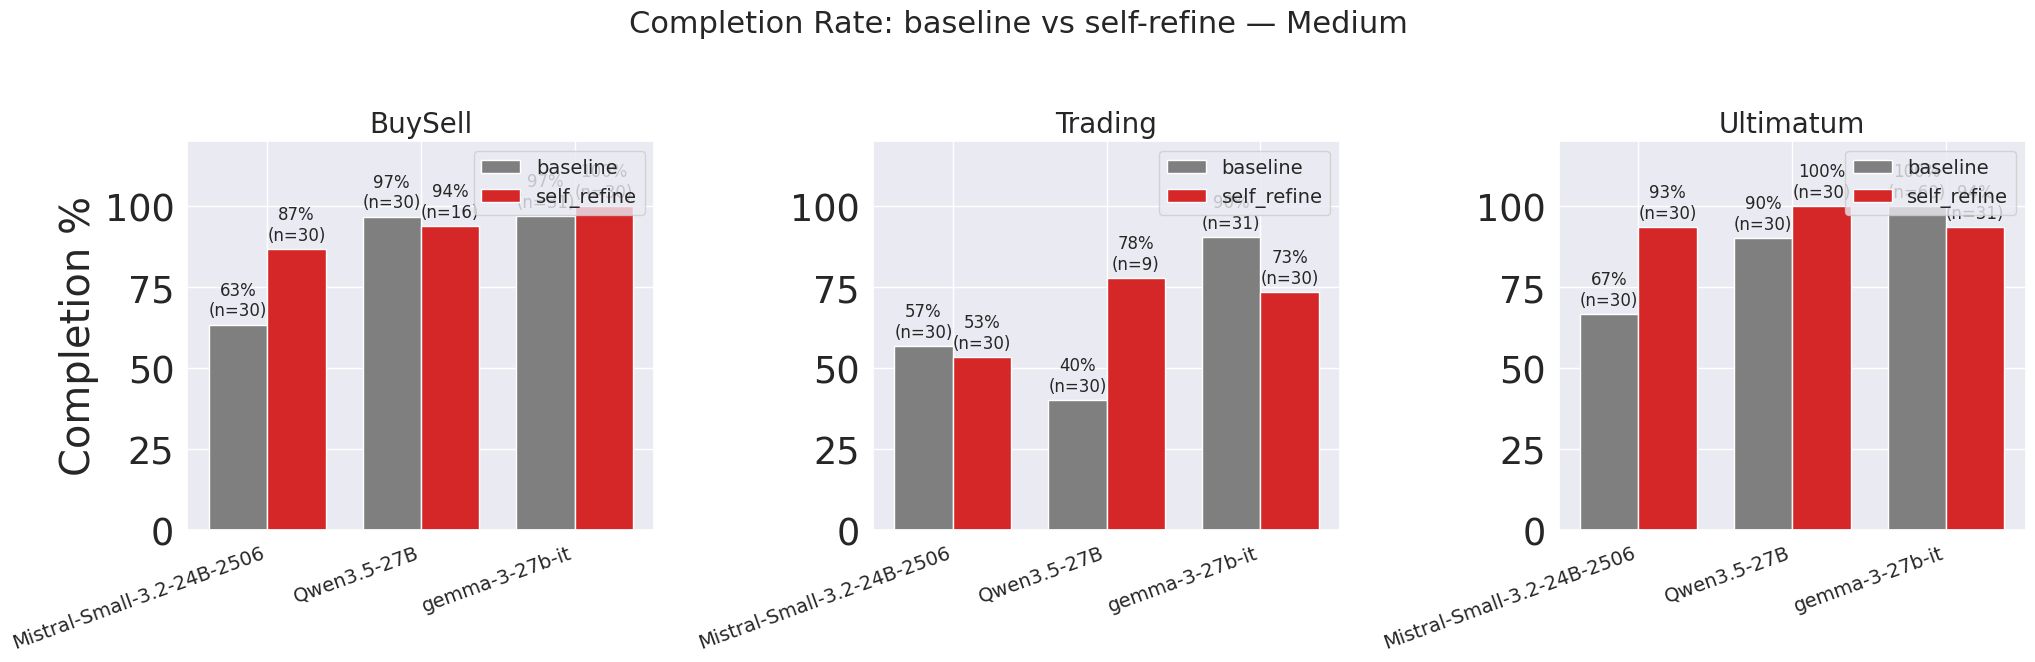

In [35]:
agg = sym_df.groupby(["game", "model_short", "strategy"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = sorted(agg["game"].unique())
fig, axes = plt.subplots(1, len(games), figsize=(7 * len(games), 7), squeeze=False)

for ax, game in zip(axes[0], games):
    sub = agg[agg["game"] == game]
    models = sorted(sub["model_short"].unique())
    x = np.arange(len(models))
    width = 0.38
    for i, strat in enumerate(STRATEGIES):
        pct = [sub[(sub["model_short"] == m) & (sub["strategy"] == strat)]["pct"].sum()
               for m in models]
        totals = [int(sub[(sub["model_short"] == m) & (sub["strategy"] == strat)]["total"].sum())
                  for m in models]
        bars = ax.bar(x + (i - 0.5) * width, pct, width,
                      label=strat, color=STRATEGY_COLORS[strat])
        for bar, v, n in zip(bars, pct, totals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 1.5,
                    f"{v:.0f}%\n(n={n})", ha="center", va="bottom", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14, rotation=20, ha="right")
    ax.set_ylim(0, 120)
    ax.set_ylabel("Completion %" if ax is axes[0][0] else "")
    ax.set_title(game, fontsize=20)
    ax.legend(fontsize=14, loc="upper right")

fig.suptitle(f"Completion Rate: baseline vs self-refine — {SIZE_LABEL}", fontsize=22)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_completion_rates.pdf", bbox_inches="tight")
plt.show()


## 2. Negotiation Outcomes

Among games that completed, does self-refine change what the agents walk away with?

- **Trading** — resource delta relative to each player's starting inventory (zero-sum under 1:1 valuation).
- **Ultimatum** — dollars each player ends up with: proposer keeps $100 − transferred, responder receives the transfer.  Rejected deals give both $0.
- **BuySell** — seller / buyer profit (`summary.player_outcome`).  Positive = profit, 0 = no-deal or break-even.


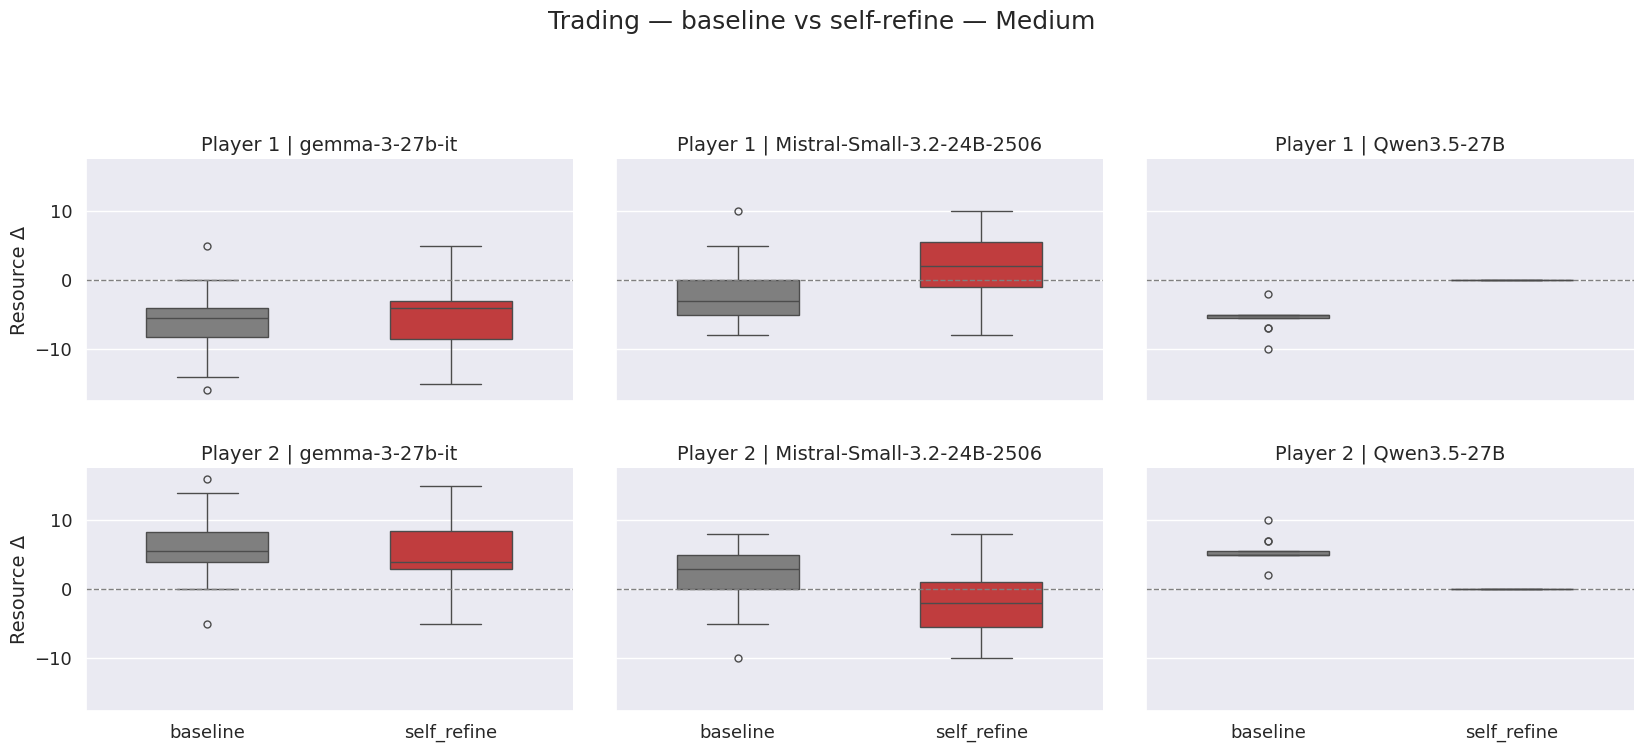

In [36]:
tdf = sym_df[(sym_df["game"] == "Trading") & sym_df["completed"] & sym_df["payoff_1"].notna()].copy()

if tdf.empty:
    print("No completed Trading runs for this size.")
else:
    plot_df = pd.melt(
        tdf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="payoff",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Player 1", "payoff_2": "Player 2"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="payoff", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="gray", ls="--", lw=1)
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Resource Δ", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"Trading — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_trading.pdf", bbox_inches="tight")
    plt.show()


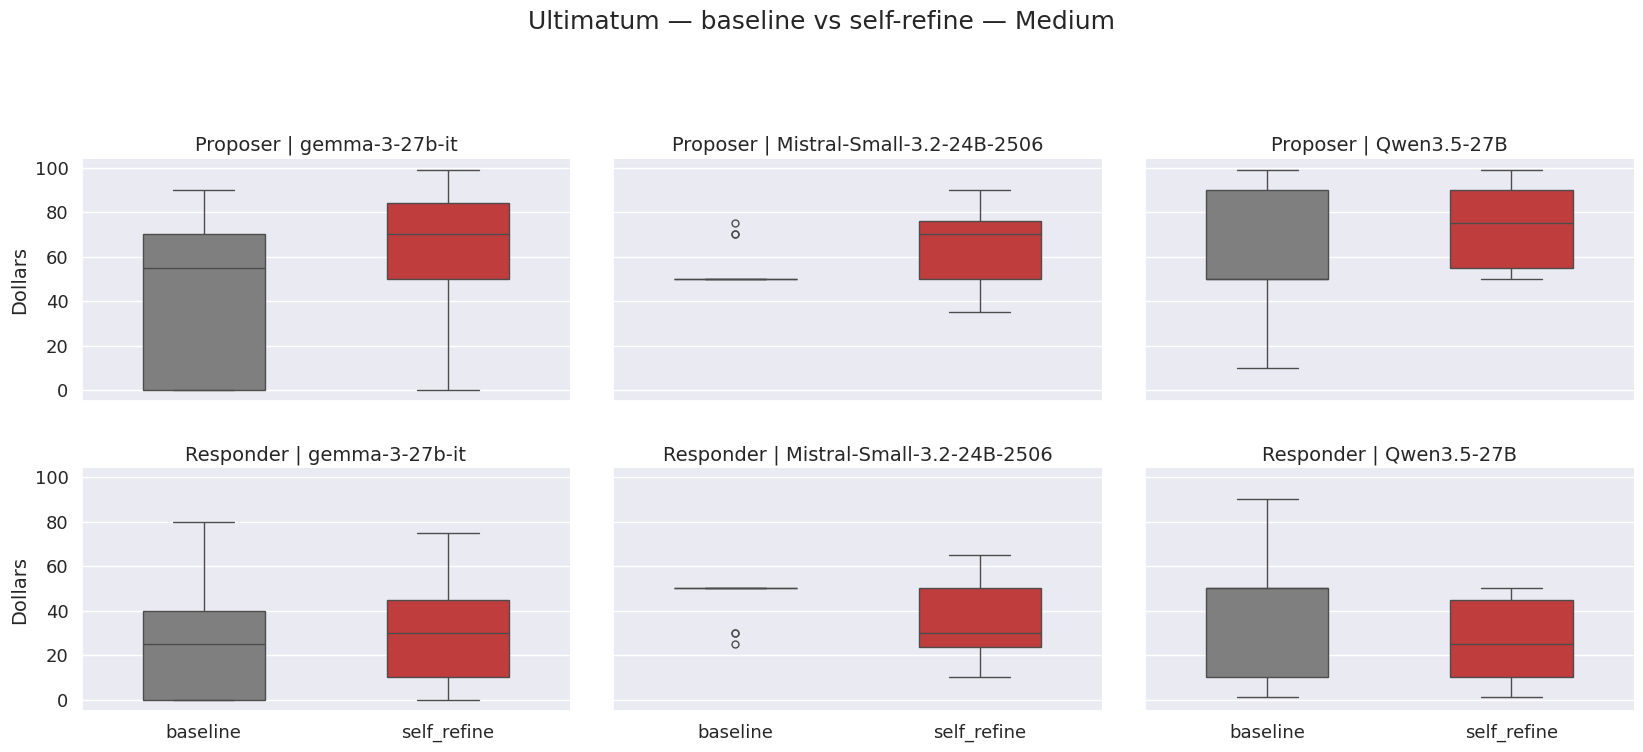


Ultimatum — ACCEPT rate:
  Mistral-Small-3.2-24B-2506            baseline      accept=100.0%  (n=20)
  Mistral-Small-3.2-24B-2506            self_refine   accept=100.0%  (n=28)
  Qwen3.5-27B                           baseline      accept=100.0%  (n=27)
  Qwen3.5-27B                           self_refine   accept=100.0%  (n=30)
  gemma-3-27b-it                        baseline      accept= 66.7%  (n=60)
  gemma-3-27b-it                        self_refine   accept= 89.7%  (n=29)


In [37]:
udf = sym_df[(sym_df["game"] == "Ultimatum") & sym_df["completed"] & sym_df["payoff_1"].notna()].copy()

if udf.empty:
    print("No completed Ultimatum runs for this size.")
else:
    plot_df = pd.melt(
        udf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="payoff",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Proposer", "payoff_2": "Responder"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="payoff", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Dollars", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"Ultimatum — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_ultimatum.pdf", bbox_inches="tight")
    plt.show()

    deal = (udf.groupby(["model_short", "strategy"])["deal"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "accept_rate", "count": "n"})
                .reset_index())
    print("\nUltimatum — ACCEPT rate:")
    for _, r in deal.iterrows():
        print(f"  {r['model_short']:<36}  {r['strategy']:<12}  "
              f"accept={r['accept_rate']*100:5.1f}%  (n={int(r['n'])})")


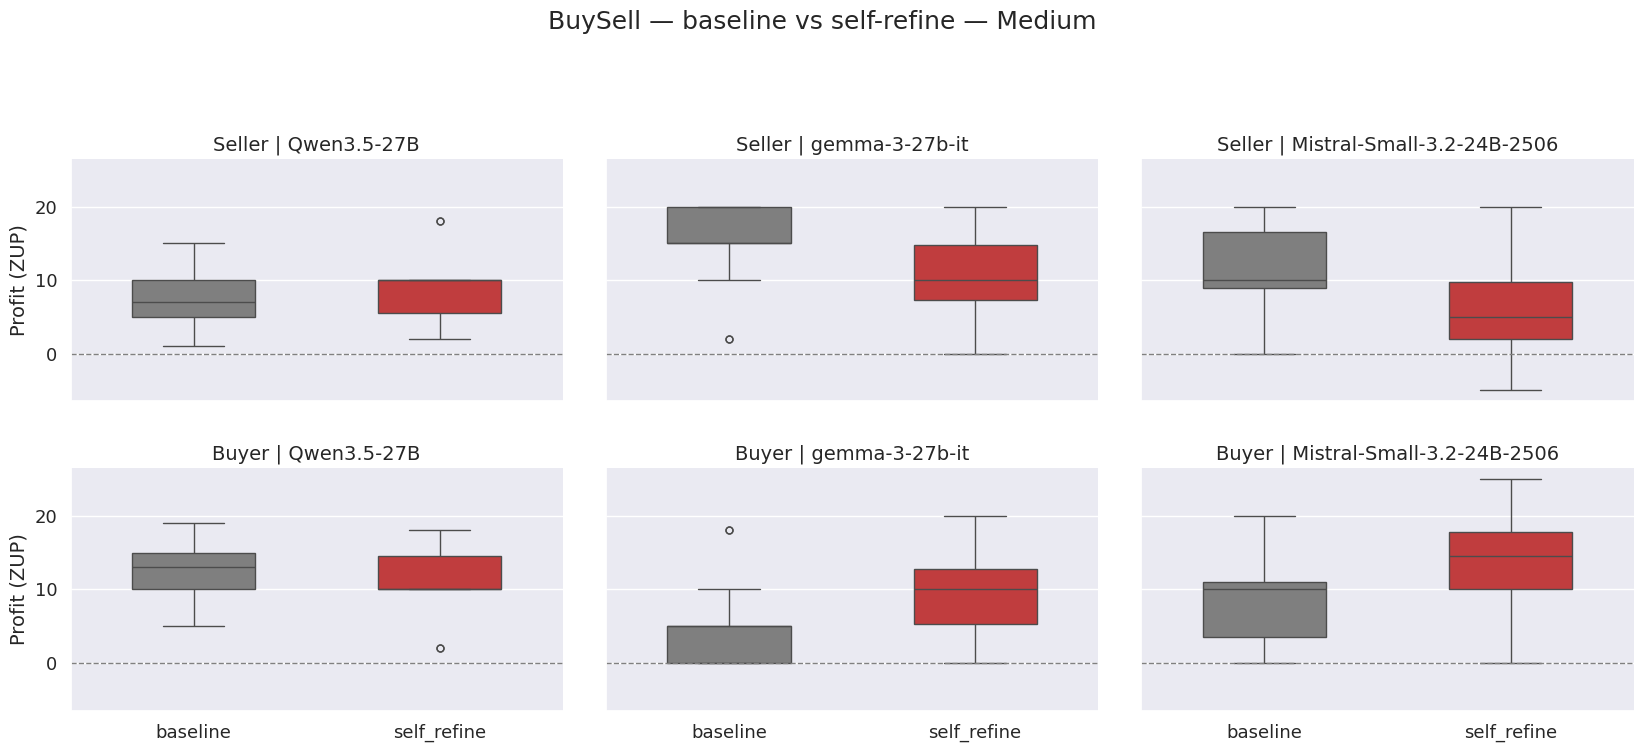

In [38]:
bdf = sym_df[(sym_df["game"] == "BuySell") & sym_df["completed"] & sym_df["payoff_1"].notna()].copy()

if bdf.empty:
    print("No completed BuySell runs for this size.")
else:
    plot_df = pd.melt(
        bdf, id_vars=["model_short", "strategy"],
        value_vars=["payoff_1", "payoff_2"],
        var_name="player", value_name="profit",
    )
    plot_df["player"] = plot_df["player"].map({"payoff_1": "Seller", "payoff_2": "Buyer"})

    g = sns.catplot(
        data=plot_df, x="strategy", y="profit", hue="strategy",
        order=STRATEGIES, palette=STRATEGY_COLORS,
        col="model_short", row="player",
        kind="box", height=3.8, aspect=1.5, width=0.5, legend=False,
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="gray", ls="--", lw=1)
        ax.tick_params(axis="x", labelsize=13)
        ax.tick_params(axis="y", labelsize=13)
    g.set_axis_labels("", "Profit (ZUP)", fontsize=14)
    g.set_titles(col_template="{col_name}", row_template="{row_name}", size=14)
    g.fig.suptitle(f"BuySell — baseline vs self-refine — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_buysell.pdf", bbox_inches="tight")
    plt.show()


## 3. Negotiation Dynamics

Self-refine agents think more per turn — does that translate into fewer *turns* (they converge faster because each message is higher-quality), more turns (they counter-propose more confidently), or no change?


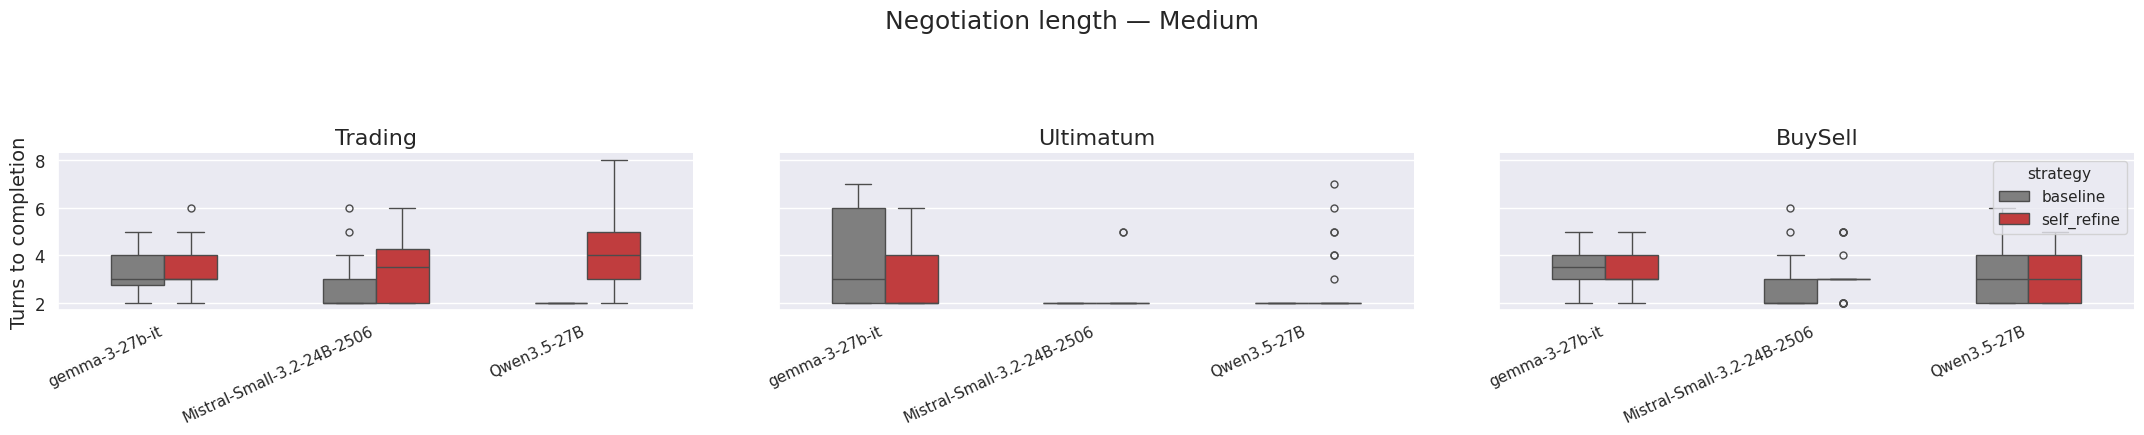

In [39]:
turns_df = sym_df[sym_df["completed"]].copy()

if turns_df.empty:
    print("No completed runs for this size.")
else:
    g = sns.catplot(
        data=turns_df, x="model_short", y="num_turns",
        hue="strategy", hue_order=STRATEGIES, palette=STRATEGY_COLORS,
        col="game", kind="box", height=4.5, aspect=1.4, width=0.5,
    )
    g.set_axis_labels("", "Turns to completion", fontsize=14)
    g.set_titles(col_template="{col_name}", size=16)
    for ax in g.axes.flatten():
        ax.tick_params(axis="x", labelsize=11, rotation=25)
        ax.tick_params(axis="y", labelsize=12)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")
    if g.legend is not None:
        g.legend.remove()
    g.axes.flatten()[-1].legend(fontsize=11, loc="upper right", title="strategy", title_fontsize=11)
    g.fig.suptitle(f"Negotiation length — {SIZE_LABEL}", fontsize=18, y=1.02)
    g.fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_turns.pdf", bbox_inches="tight")
    plt.show()


## 4. Parse Retries

Self-refine issues more LLM calls per turn (draft → feedback → refine), giving more opportunities for malformed output. Do the extra calls inflate `total_parse_retries`?


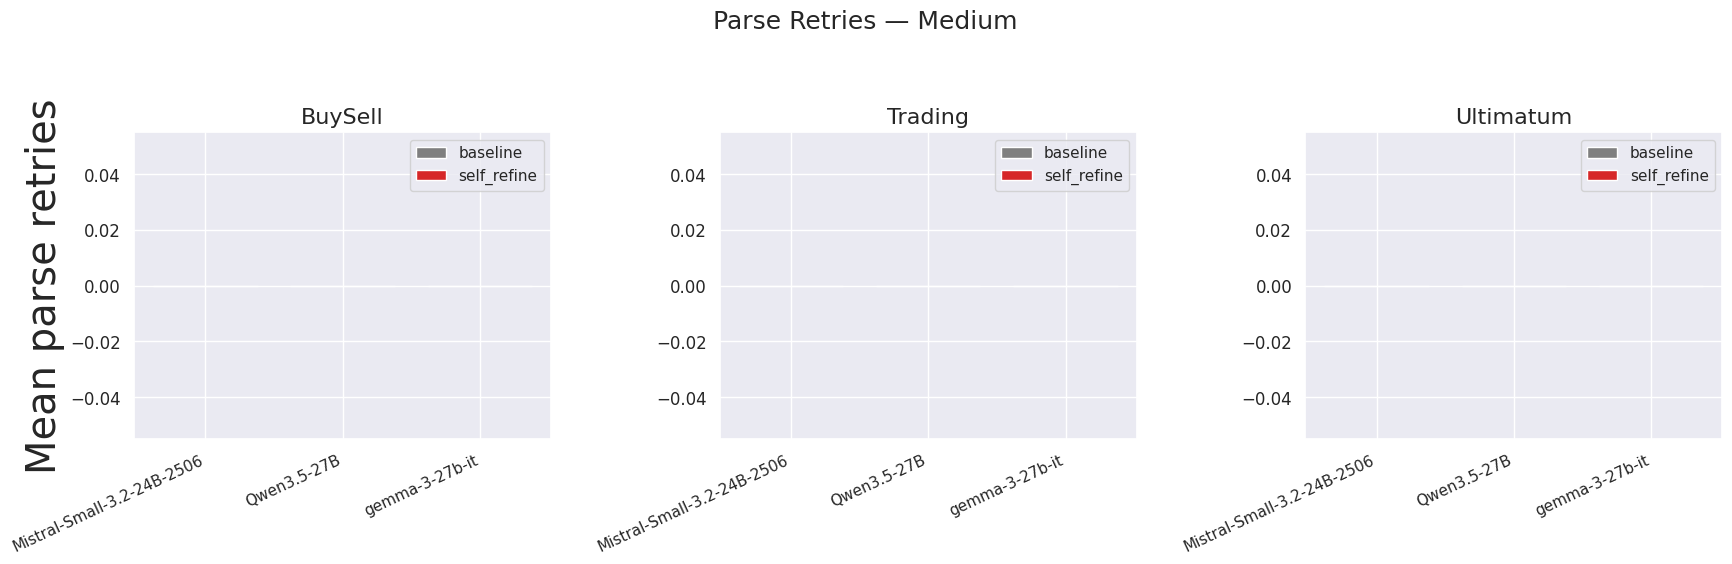

In [40]:
sym_df = df[df["strategy"].isin(STRATEGIES)].copy()
retries = (
    sym_df.groupby(["game", "model_short", "strategy"])
    .agg(mean_retries=("total_parse_retries", "mean"),
         max_retries=("total_parse_retries", "max"),
         n=("total_parse_retries", "count"))
    .reset_index()
)

games = sorted(retries["game"].unique())
fig, axes = plt.subplots(1, len(games), figsize=(6 * len(games), 6), squeeze=False)

for ax, game in zip(axes[0], games):
    sub = retries[retries["game"] == game]
    models = sorted(sub["model_short"].unique())
    x = np.arange(len(models))
    width = 0.38
    for i, strat in enumerate(STRATEGIES):
        vals = [sub[(sub["model_short"] == m) & (sub["strategy"] == strat)]["mean_retries"].sum()
                for m in models]
        ax.bar(x + (i - 0.5) * width, vals, width,
               label=strat, color=STRATEGY_COLORS[strat])
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11, rotation=25, ha="right")
    ax.set_ylabel("Mean parse retries" if ax is axes[0][0] else "")
    ax.set_title(game, fontsize=16)
    ax.legend(fontsize=11)
    ax.tick_params(axis="y", labelsize=12)

fig.suptitle(f"Parse Retries — {SIZE_LABEL}", fontsize=18)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_retries.pdf", bbox_inches="tight")
plt.show()


## 5. Summary Table

Aggregate view: per (game, model, strategy) — n, completion rate, mean payoffs, surplus, and turns.


In [41]:
summary_rows = []
sym_df = df[df["strategy"].isin(STRATEGIES)].copy()

for game in sorted(sym_df["game"].unique()):
    for model in sorted(sym_df[sym_df["game"] == game]["model_short"].unique()):
        for strat in STRATEGIES:
            sub = sym_df[
                (sym_df["game"] == game)
                & (sym_df["model_short"] == model)
                & (sym_df["strategy"] == strat)
            ]
            if sub.empty:
                continue
            done = sub[sub["completed"]]
            row = {
                "game": game,
                "model": model,
                "strategy": strat,
                "n": len(sub),
                "completed": int(sub["completed"].sum()),
                "completion_%": round(sub["completed"].mean() * 100, 1),
                "mean_P1": round(done["payoff_1"].mean(), 2) if not done["payoff_1"].isna().all() else "—",
                "mean_P2": round(done["payoff_2"].mean(), 2) if not done["payoff_2"].isna().all() else "—",
                "mean_surplus": round(done["surplus"].mean(), 2) if not done.empty else "—",
                "mean_turns": round(done["num_turns"].mean(), 1) if not done.empty else "—",
                "mean_retries": round(sub["total_parse_retries"].mean(), 2),
            }
            summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
display(summary.to_string(index=False))


'     game                      model    strategy  n  completed  completion_%  mean_P1  mean_P2  mean_surplus  mean_turns  mean_retries\n  BuySell Mistral-Small-3.2-24B-2506    baseline 30         19          63.3    11.37     8.63         20.00         2.8           0.0\n  BuySell Mistral-Small-3.2-24B-2506 self_refine 30         26          86.7     6.23    13.00         19.23         3.2           0.0\n  BuySell                Qwen3.5-27B    baseline 30         29          96.7     7.66    12.34         20.00         3.3           0.0\n  BuySell                Qwen3.5-27B self_refine 16         15          93.8     9.13    10.87         20.00         2.9           0.0\n  BuySell             gemma-3-27b-it    baseline 31         30          96.8    15.30     4.70         20.00         3.6           0.0\n  BuySell             gemma-3-27b-it self_refine 30         30         100.0    10.70     9.30         20.00         3.4           0.0\n  Trading Mistral-Small-3.2-24B-2506    baselin

## 6. Cross-Play: Does Self-Refine Confer a Per-Player Advantage?

We also have **asymmetric** conditions where one player uses self-refine while the opponent plays default (one-shot). 

This lets us ask whether self-refine is individually profitable — i.e., does the refining player gain at the other's expense  or whether both strategies produce similar outcomes regardless of what the opponent does.

Four conditions are compared:

| Condition | P1 strategy | P2 strategy |
|---|---|---|
| `base × base` | default | default |
| `refine × refine` | self_refine | self_refine |
| `base × refine` | default | self_refine |
| `refine × base` | self_refine | default |

> **Note on sample sizes:** Asymmetric cells (base × refine, refine × base) have n ≈ 3 runs each — treat those bars as **directional only**, not conclusive.  


 A. Per-player payoff across all conditions 


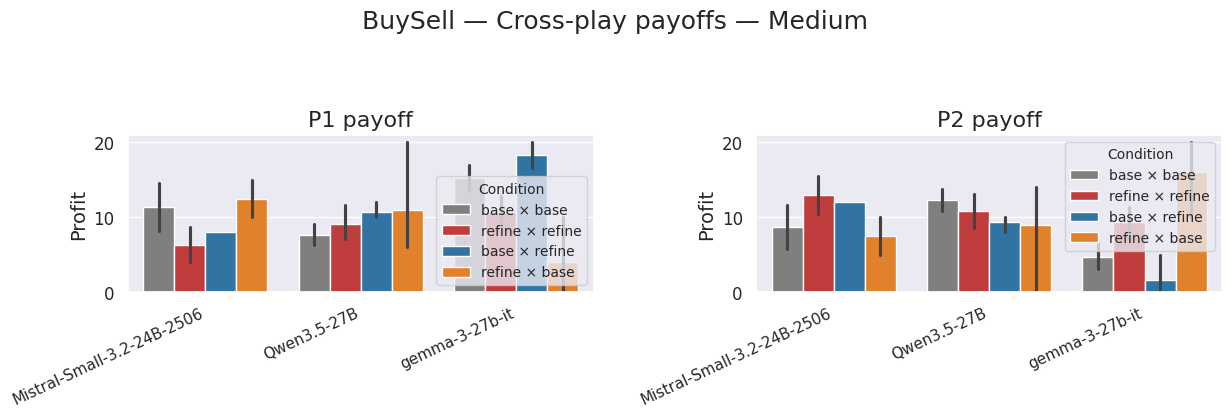

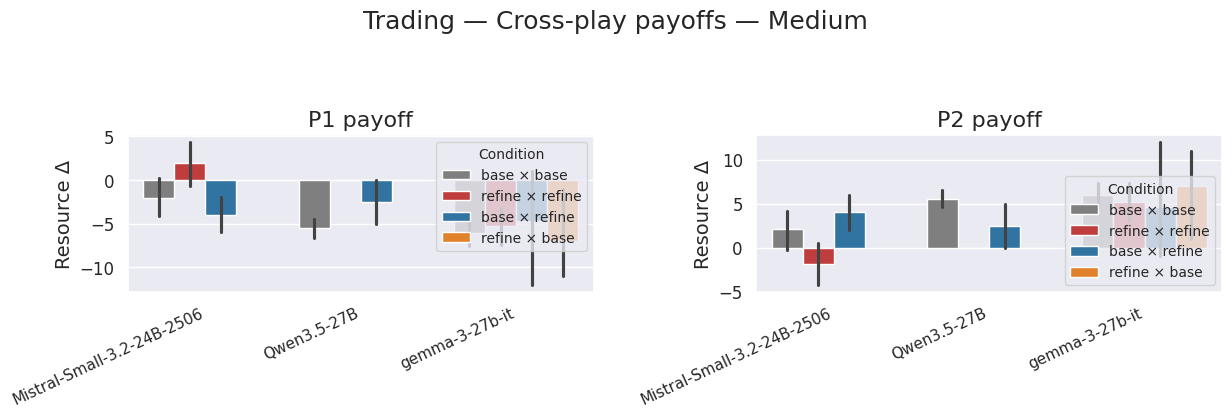

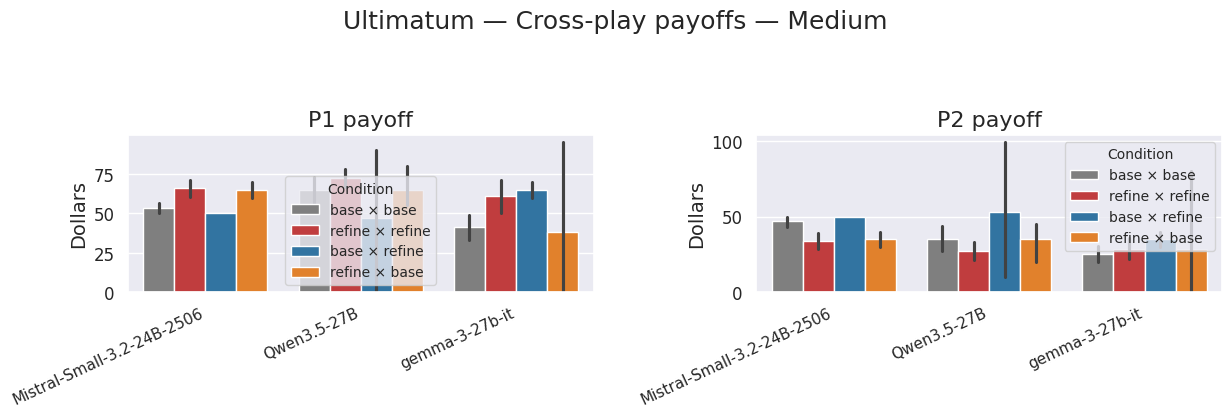

In [42]:
# Cross-play data: all 4 conditions, completed runs with payoff data
cp_df = df[df["cond"].notna() & df["completed"] & df["payoff_1"].notna()].copy()
avail_conds = [c for c in COND_ORDER if c in cp_df["cond"].unique()]

if len(avail_conds) < 3:
    print(
        f"Cross-play data not available for MODEL_SIZE='{MODEL_SIZE}'. "
        "Switch to 'medium' which has all four conditions."
    )
else:
    palette = {c: COND_COLORS[c] for c in avail_conds}
    games_here = sorted(cp_df["game"].unique())
    YLABEL_MAP = {"Trading": "Resource Δ", "BuySell": "Profit", "Ultimatum": "Dollars"}

    # Per-player payoff by condition
    print(" A. Per-player payoff across all conditions ")
    for game in games_here:
        sub_g = cp_df[cp_df["game"] == game]
        if sub_g.empty:
            continue
        ylabel = YLABEL_MAP.get(game, "Payoff")
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
        for ax, (col, title) in zip(axes, [("payoff_1", "P1"), ("payoff_2", "P2")]):
            sub = sub_g.dropna(subset=[col])
            if sub.empty:
                ax.set_visible(False)
                continue
            models = sorted(sub["model_short"].unique())
            sns.barplot(
                data=sub, x="model_short", y=col,
                hue="cond", hue_order=avail_conds, palette=palette,
                order=models, errorbar=("ci", 95), ax=ax,
            )
            ax.set_title(f"{title} payoff", fontsize=16)
            ax.set_ylabel(ylabel, fontsize=14)
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=11, rotation=25)
            ax.tick_params(axis="y", labelsize=12)
            for lbl in ax.get_xticklabels():
                lbl.set_ha("right")
            ax.legend(fontsize=10, title="Condition", title_fontsize=10)
        fig.suptitle(f"{game} — Cross-play payoffs — {SIZE_LABEL}", fontsize=18)
        fig.tight_layout()
        plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_crossplay_{game.lower()}_payoff.pdf",
                    bbox_inches="tight")
        plt.show()


 B. Advantage Δ vs base × base 
Positive Δ P1 under 'refine × base' means the self-refine player gains vs one-shot opponent.



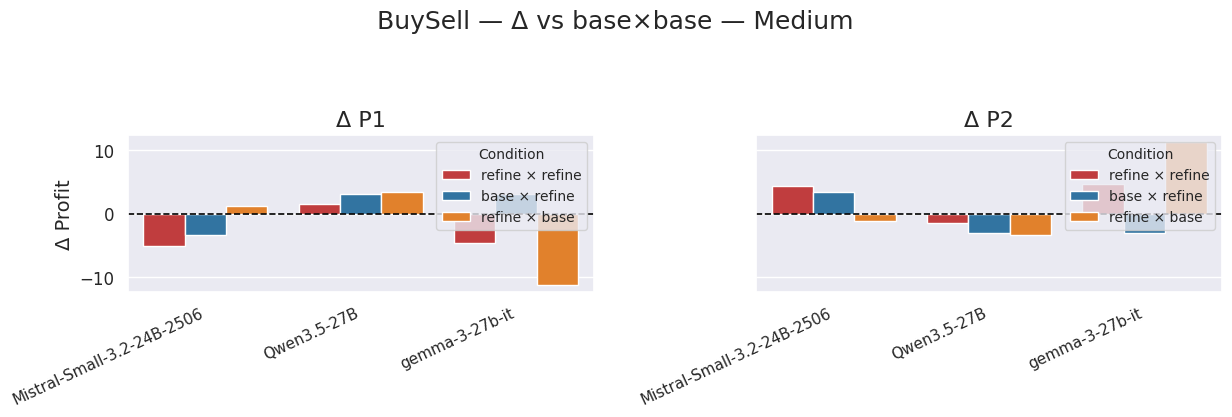

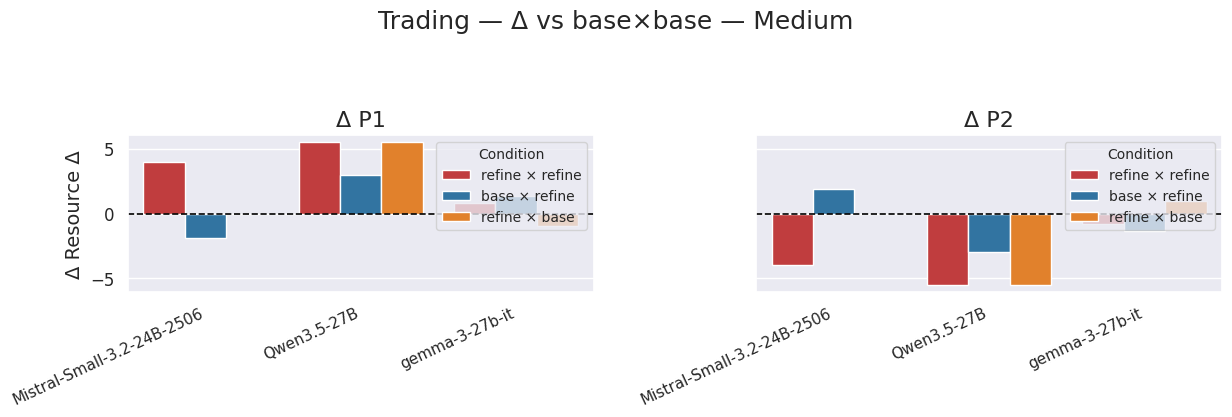

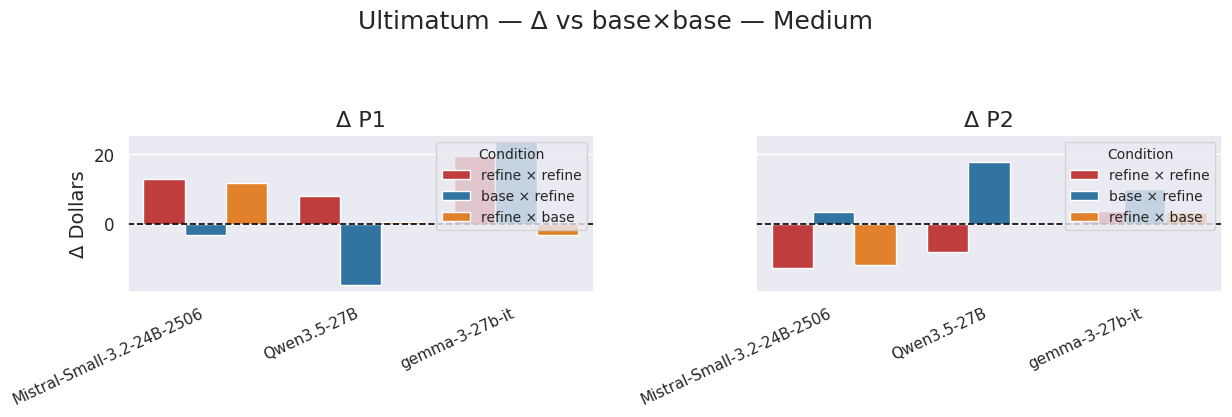

In [43]:
#  Section B: Δ advantage vs base × base
BASELINE_COND = "base × base"

if len(avail_conds) < 3:
    print("Skipping Δ chart: insufficient conditions.")
elif BASELINE_COND not in avail_conds:
    print(f"No '{BASELINE_COND}' data for size '{MODEL_SIZE}' — cannot compute Δ. Use 'medium'.")
else:
    non_base = [c for c in avail_conds if c != BASELINE_COND]
    non_base_palette = {c: COND_COLORS[c] for c in non_base}
    games_here = sorted(cp_df["game"].unique())
    YLABEL_MAP = {"Trading": "Resource Δ", "BuySell": "Profit", "Ultimatum": "Dollars"}

    print(" B. Advantage Δ vs base × base ")
    print("Positive Δ P1 under 'refine × base' means the self-refine player gains vs one-shot opponent.\n")

    for game in games_here:
        sub_g = cp_df[cp_df["game"] == game].dropna(subset=["payoff_1"])
        if sub_g.empty:
            continue
        means = (
            sub_g.groupby(["model_short", "cond"])[["payoff_1", "payoff_2"]]
            .mean()
            .reset_index()
        )
        base_m = (
            means[means["cond"] == BASELINE_COND][["model_short", "payoff_1", "payoff_2"]]
            .rename(columns={"payoff_1": "b1", "payoff_2": "b2"})
        )
        delta = means.merge(base_m, on="model_short", how="inner")
        delta["Δ P1"] = delta["payoff_1"] - delta["b1"]
        delta["Δ P2"] = delta["payoff_2"] - delta["b2"]
        delta = delta[delta["cond"].isin(non_base)]
        if delta.empty:
            continue

        ylabel = YLABEL_MAP.get(game, "Payoff")
        models = sorted(delta["model_short"].unique())
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
        for ax, col in zip(axes, ["Δ P1", "Δ P2"]):
            sns.barplot(
                data=delta, x="model_short", y=col,
                hue="cond", hue_order=non_base, palette=non_base_palette,
                order=models, ax=ax,
            )
            ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
            ax.set_title(col, fontsize=16)
            ax.set_ylabel(f"Δ {ylabel}", fontsize=14)
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=11, rotation=25)
            ax.tick_params(axis="y", labelsize=12)
            for lbl in ax.get_xticklabels():
                lbl.set_ha("right")
            ax.legend(fontsize=10, title="Condition", title_fontsize=10)
        fig.suptitle(f"{game} — Δ vs base×base — {SIZE_LABEL}", fontsize=18)
        fig.tight_layout()
        plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_crossplay_{game.lower()}_delta.pdf",
                    bbox_inches="tight")
        plt.show()


 C. Joint welfare by condition 


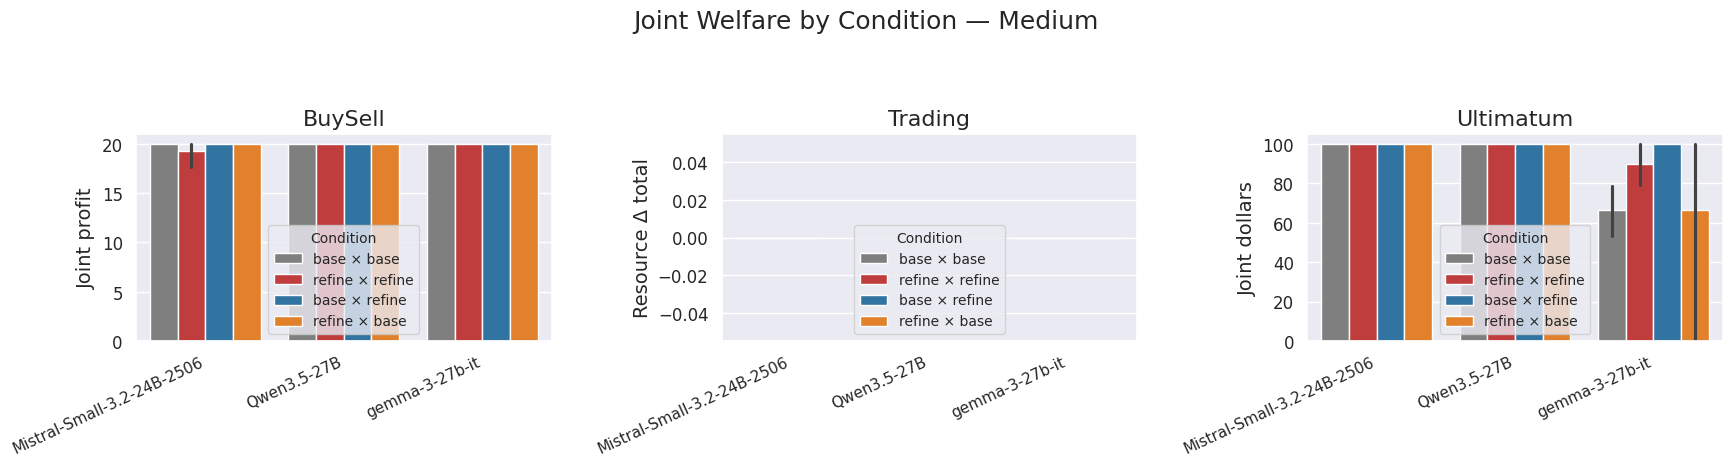

In [44]:
#  Section C: Joint welfare by condition 
welfare_cp = df[df["cond"].notna() & df["completed"]].dropna(subset=["surplus"]).copy()
avail_conds_w = [c for c in COND_ORDER if c in welfare_cp["cond"].unique()]

if len(avail_conds_w) < 3:
    print("Skipping joint welfare chart: insufficient cross-play conditions for this size.")
else:
    palette_w = {c: COND_COLORS[c] for c in avail_conds_w}
    games_here = sorted(welfare_cp["game"].unique())
    YLABEL_MAP = {"Trading": "Resource Δ total", "BuySell": "Joint profit", "Ultimatum": "Joint dollars"}

    print(" C. Joint welfare by condition ")
    fig, axes = plt.subplots(1, len(games_here), figsize=(6 * len(games_here), 5), squeeze=False)

    for ax, game in zip(axes[0], games_here):
        sub = welfare_cp[welfare_cp["game"] == game]
        if sub.empty:
            ax.set_visible(False)
            continue
        models = sorted(sub["model_short"].unique())
        sns.barplot(
            data=sub, x="model_short", y="surplus",
            hue="cond", hue_order=avail_conds_w, palette=palette_w,
            order=models, errorbar=("ci", 95), ax=ax,
        )
        ax.set_title(game, fontsize=16)
        ax.set_ylabel(YLABEL_MAP.get(game, "Joint welfare"), fontsize=14)
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=11, rotation=25)
        ax.tick_params(axis="y", labelsize=12)
        for lbl in ax.get_xticklabels():
            lbl.set_ha("right")
        ax.legend(fontsize=10, title="Condition", title_fontsize=10)

    fig.suptitle(f"Joint Welfare by Condition — {SIZE_LABEL}", fontsize=18)
    fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/self_refine_{MODEL_SIZE}_crossplay_joint_welfare.pdf",
                bbox_inches="tight")
    plt.show()
